# packages from previous codes
import os
import json
import glob
from dotenv import load_dotenv
import google.generativeai as genai
import tqdm
from tqdm import tqdm_notebook
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import stanza

In [ ]:
load_dotenv()
plt.style.use('ggplot')
tqdm_notebook()

In [2]:
# stanza.download('hu')
# nlp = stanza.Pipeline('hu', processors='tokenize,pos,lemma', use_gpu=False)
nlp = stanza.Pipeline('hu', processors='tokenize,lemma,ner,pos,depparse',use_gpu=False)

2026-05-07 18:14:54 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-05-07 18:14:54 INFO: Downloaded file to /Users/mac/Library/Caches/stanza/1.11.0/resources/resources.json
2026-05-07 18:15:08 INFO: Loading these models for language: hu (Hungarian):
| Processor | Package         |
-------------------------------
| tokenize  | szeged          |
| pos       | szeged_nocharlm |
| lemma     | szeged_nocharlm |
| depparse  | szeged_nocharlm |
| ner       | combined        |

2026-05-07 18:15:08 INFO: Using device: cpu
2026-05-07 18:15:08 INFO: Loading: tokenize
2026-05-07 18:15:09 INFO: Loading: pos
2026-05-07 18:15:10 INFO: Loading: lemma
2026-05-07 18:15:10 INFO: Loading: depparse
2026-05-07 18:15:10 INFO: Loading: ner
2026-05-07 18:15:13 INFO: Done loading processors!


### Read-in JSON files

In [3]:
path = os.getenv('PROJECT_DIR')+'/transcripts_corrected/*.json'
files = glob.glob(path)

In [4]:
df = pd.DataFrame([json.load(open(f)) for f in files])
df['date'] = pd.to_datetime(df['filename'].str.extract(r'(\d{8})')[0], format='%Y%m%d')
df = df.drop(columns=['url', 'filename'])[['date', 'raw_text']]
df=df.sort_values('date')
df = df.reset_index(drop=True)

### Create news dataset

In [5]:
news_collection = []

for index, column in tqdm.tqdm(df.iterrows()):
    doc = nlp(df.loc[index, 'raw_text']).to_dict()

    data = []

    for i in doc:
        for j in i:
            mini_df = pd.DataFrame.from_dict(j, orient='index').T
            data.append(mini_df)

    one_news=pd.concat(data)
    one_news['date']=column['date']
    news_collection.append(one_news)

23it [01:04,  2.82s/it]


In [6]:
news=pd.concat(news_collection)
news=news.reset_index(drop=True)

# merge together the names following each other
is_entity_start = news['ner'].str.startswith('B-')
is_not_entity = news['ner'] == 'O'
upos_changed = news['upos'] != news['upos'].shift()
news['group'] = (is_entity_start | (is_not_entity & upos_changed)).cumsum()
news = news.groupby('group').agg({
    'id': 'first',
    'text': lambda x: ' '.join(x),
    'lemma': lambda x: ' '.join(x),
    'upos': 'first',
    'ner': 'first',  # Keep the entity type (e.g., S-PER, B-ORG)
    'feats': 'first',
    'deprel': 'first',
    'date': 'first'
}).reset_index(drop=True)

# filter out the unnecessary characters and words
news = news[~news.upos.isin(['DET', 'CCONJ', 'SCONJ', 'PRON', 'PUNCT', 'ADP', 'AUX'])]
news_stopwords = ['nem', 'meg', 'kell', 'van', 'mond', 'lesz', 'volt', 'is', 'ez', 'az', 'hogy', 
'mond', 'beszél', 'el', 'ki', 'önöket', 'Székely-Varga Edina', '[cite']
news=news[~news.lemma.isin(news_stopwords)]

In [7]:
news['next_lemma']=news.lemma.shift(-1)

def fix_problematic_lemmas(lemma):
    correction_map = {
        'Orbán Viktort': 'Orbán Viktor',
        'Magyar Pétert': 'Magyar Péter',
        'J. 1. Vance': 'J. D. Vance'
    }
    
    if lemma in correction_map:
        return correction_map[lemma]
    
    return lemma

# Alkalmazása a DataFrame-en:
news['lemma'] = news['lemma'].apply(fix_problematic_lemmas)

In [8]:
news

,id,text,lemma,upos,ner,feats,deprel,date,next_lemma
0,1,Titkos,titkos,ADJ,O,Case=Nom|Degree=Pos|Number=Sing,amod:att,2026-03-30,tisza-terv
1,2,Tisza-tervet,tisza-terv,NOUN,O,Case=Acc|Number=Sing,obj,2026-03-30,hoz
2,3,hozott,hoz,VERB,O,Definite=Ind|Mood=Ind|Number=Sing|Person=3|Ten...,root,2026-03-30,nyilvánosság
3,4,nyilvánosságra,nyilvánosság,NOUN,O,Case=Sbl|Number=Sing,obl,2026-03-30,Csere Balázs
4,5,Csere Balázs,Csere Balázs,PROPN,B-PER,Case=Nom|Number=Sing,nsubj,2026-03-30,ki+vez
...,...,...,...,...,...,...,...,...,...
34235,3,25,25,NUM,O,Case=Nom|NumType=Card|Number=Sing,parataxis,2026-04-25,marad
34244,1,Maradjanak,marad,VERB,O,Definite=Ind|Mood=Imp|Number=Plur|Person=3|Ten...,root,2026-04-25,nemsokára
34247,4,nemsokára,nemsokára,ADV,O,None,advmod:tlocy,2026-04-25,kezdődik
34248,5,kezdődik,kezdődik,VERB,O,Definite=Ind|Mood=Ind|Number=Sing|Person=3|Ten...,conj,2026-04-25,Nemzeti Sporthíradó Könyves Bence


In [9]:
news.lemma.value_counts().reset_index()

,lemma,count
0,Magyar Péter,115
1,magyar,110
2,Orbán Viktor,109
3,elnök,101
4,kormány,74
...,...,...
6570,általában csak,1
6571,csípőműtéte,1
6572,1995-ös,1
6573,hatvanas,1


### Analysis

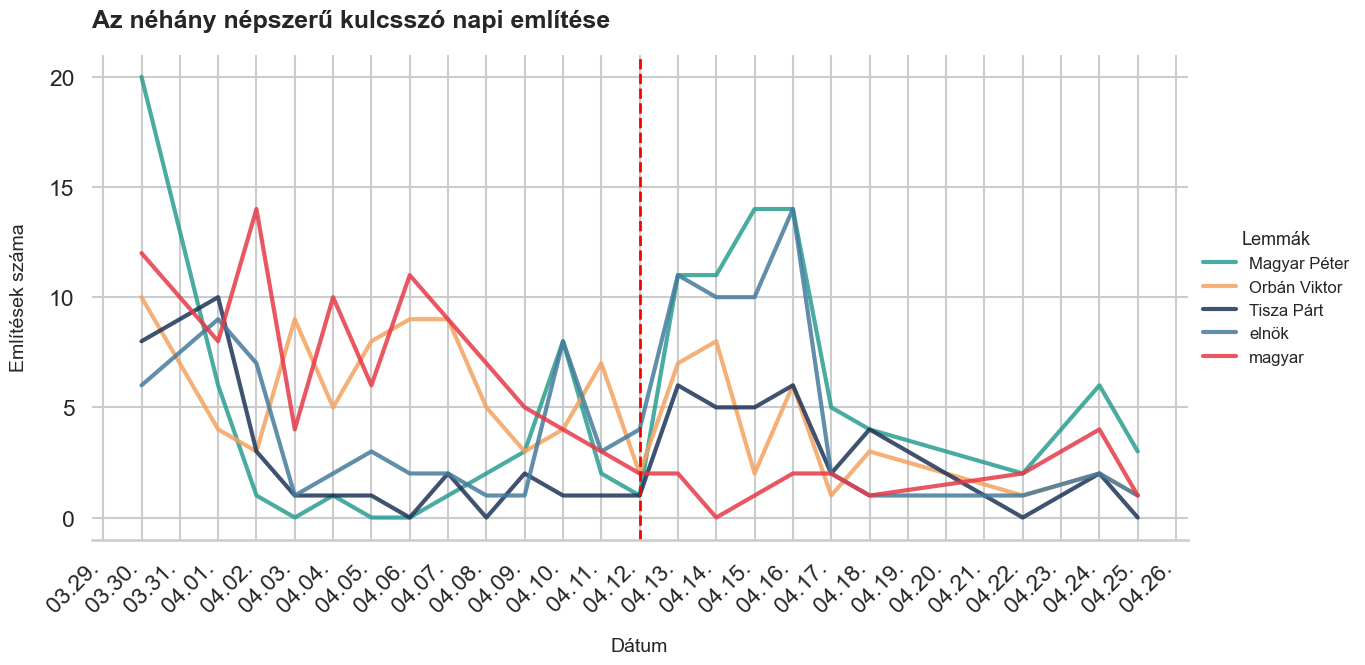

In [10]:
# selecting the top words
daily_counts = news.groupby(['date', 'lemma']).size().reset_index(name='count')
# top_lemmas = news['lemma'].value_counts().head(5).index.tolist()
top_lemmas = ['magyar', 'elnök', 'Magyar Péter', 'Orbán Viktor', 'Tisza Párt']
trend_data = daily_counts[daily_counts['lemma'].isin(top_lemmas)]
trend_pivot = trend_data.pivot(index='date', columns='lemma', values='count').fillna(0)

# plotting
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7))

palette = {
    'magyar': '#e63946',   # Piros
    'elnök': '#457b9d', # Kék
    'Magyar Péter': '#2a9d8f',   # Zöld
    'Orbán Viktor': '#f4a261',# Narancs
    'Tisza Párt': '#1d3557'  # Sötétkék
}

trend_pivot.plot(ax=ax, linewidth=3, alpha=0.85, color=palette)
ax.set_title('Az néhány népszerű kulcsszó napi említése', 
    fontsize=18, fontweight='bold', pad=20, loc='left')

ax.set_ylabel('Említések száma', fontsize=14, labelpad=15)
ax.set_xlabel('Dátum', fontsize=14, labelpad=15)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m.%d.'))
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

ax.axvline(pd.to_datetime('2026-04-12'), color='red', linewidth=2, linestyle='--')
ax.legend(title='Lemmák', title_fontsize='13', fontsize='12', 
loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Network Analysis

In [12]:
import itertools
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

In [13]:
cooccurrences = []

In [560]:
import pandas as pd
import itertools
from collections import Counter
import networkx as nx

def generate_cooccurrence_graph(df, min_cooccurrence=15, before_election=True):
    """
    Generates a NetworkX graph based on entity co-occurrences within a 
    3-sentence sliding window, filtered by the election period.
    """
    # 1. Setup election boundary
    election_date = pd.to_datetime('2026-04-12')
    
    # 2. Filter by period
    if before_election:
        work_df = df[df['date'] < election_date].copy()
    else:
        work_df = df[df['date'] >= election_date].copy()
        
    if work_df.empty:
        print("No data found for the selected period.")
        return nx.Graph()

    # 3. Ensure sentence_id is correctly calculated for this subset
    # We assume 'id' == 1 marks the start of a new sentence
    work_df['sentence_uid'] = (work_df['id'] == 1).cumsum()

    # 4. Filter for Proper Nouns and group by the unique sentence ID
    propn_news = work_df[work_df['upos'] == 'PROPN'].dropna(subset=['lemma'])
    sentence_entities = propn_news.groupby('sentence_uid')['lemma'].apply(
        lambda x: sorted(list(set(x)))
    ).to_dict()

    # 5. Sliding window logic (Current + 2 following sentences)
    all_sentence_ids = sorted(sentence_entities.keys())
    cooccurrences = []

    for i in range(len(all_sentence_ids)):
        # Define window range (current sentence + next two)
        window_ids = all_sentence_ids[i : i + 3]
        
        window_entities = []
        for s_id in window_ids:
            window_entities.extend(sentence_entities[s_id])
        
        # Deduplicate entities across the 3-sentence block
        unique_window_entities = sorted(list(set(window_entities)))

        if len(unique_window_entities) >= 2:
            pairs = list(itertools.combinations(unique_window_entities, 2))
            cooccurrences.extend(pairs)

    # 6. Count pairs and build the Graph
    pair_counts = Counter(cooccurrences)
    G = nx.Graph()
    
    for (node1, node2), weight in pair_counts.items():
        if weight >= min_cooccurrence:
            G.add_edge(node1, node2, weight=weight)

    period_str = "BEFORE" if before_election else "AFTER"
    print(f"Graph generated for {period_str} election period.")
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    
    return G

Graph generated for BEFORE election period.
Nodes: 17, Edges: 27


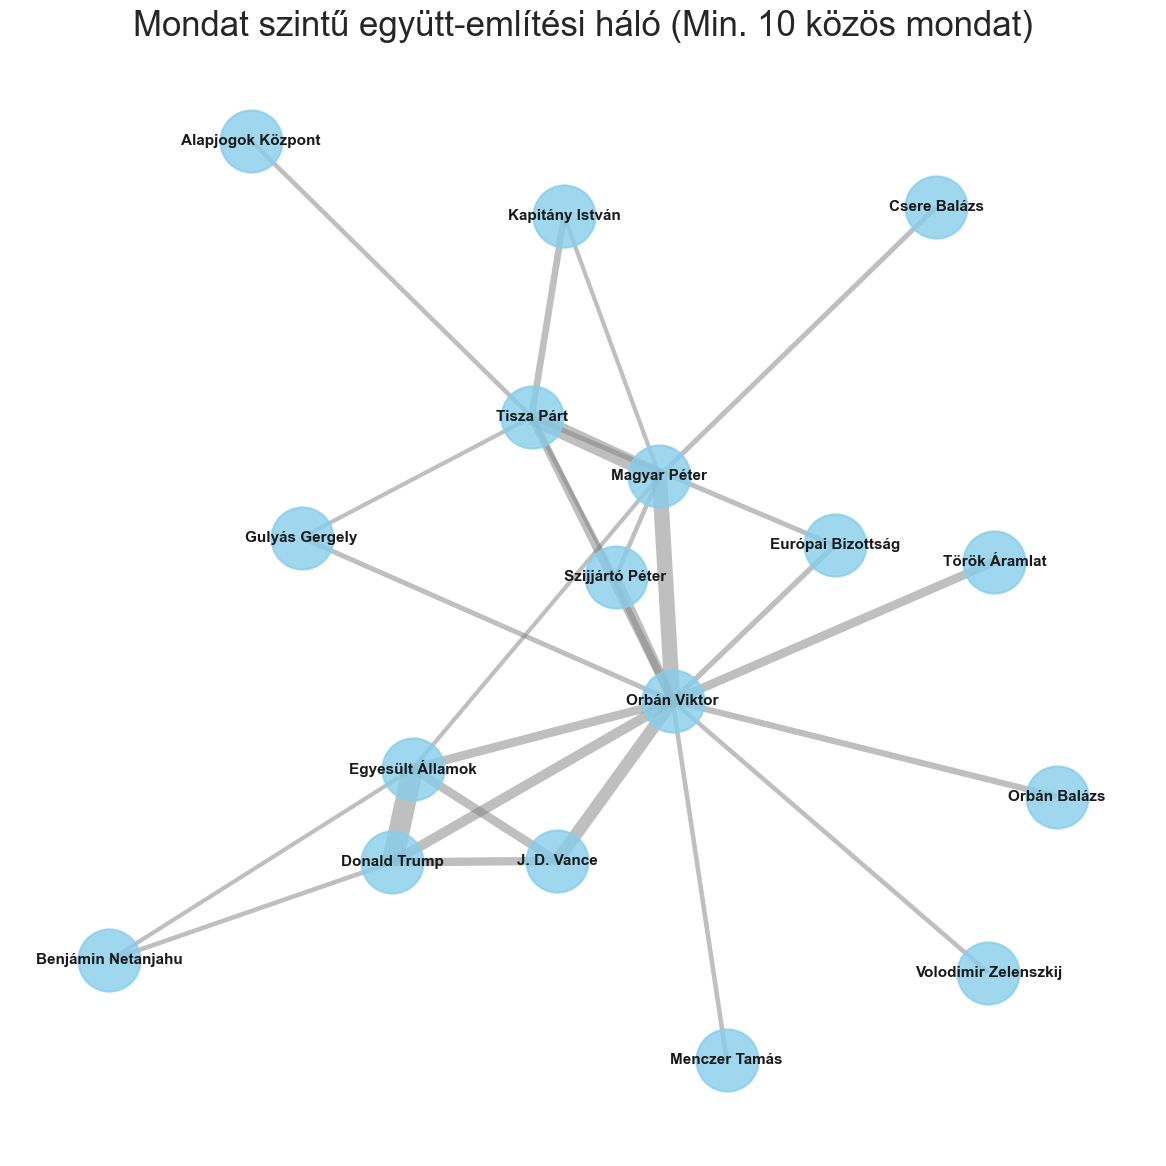

In [562]:
plt.figure(figsize=(12, 12))
    
# line's width based on frequency
min_cooccurrence = 10
G =  generate_cooccurrence_graph(news, min_cooccurrence=min_cooccurrence, before_election=True)
edges = G.edges()
weights = [G[u][v]['weight']*3 / min_cooccurrence for u, v in edges]

pos = nx.spring_layout(G, k=1, iterations=50, seed = 4) 
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

plt.title(f'Mondat szintű együtt-említési háló (Min. {min_cooccurrence} közös mondat)', fontsize=25)
plt.axis('off') # Hálózatnál a keret felesleges
plt.tight_layout()
plt.show()

Graph generated for AFTER election period.
Nodes: 12, Edges: 18


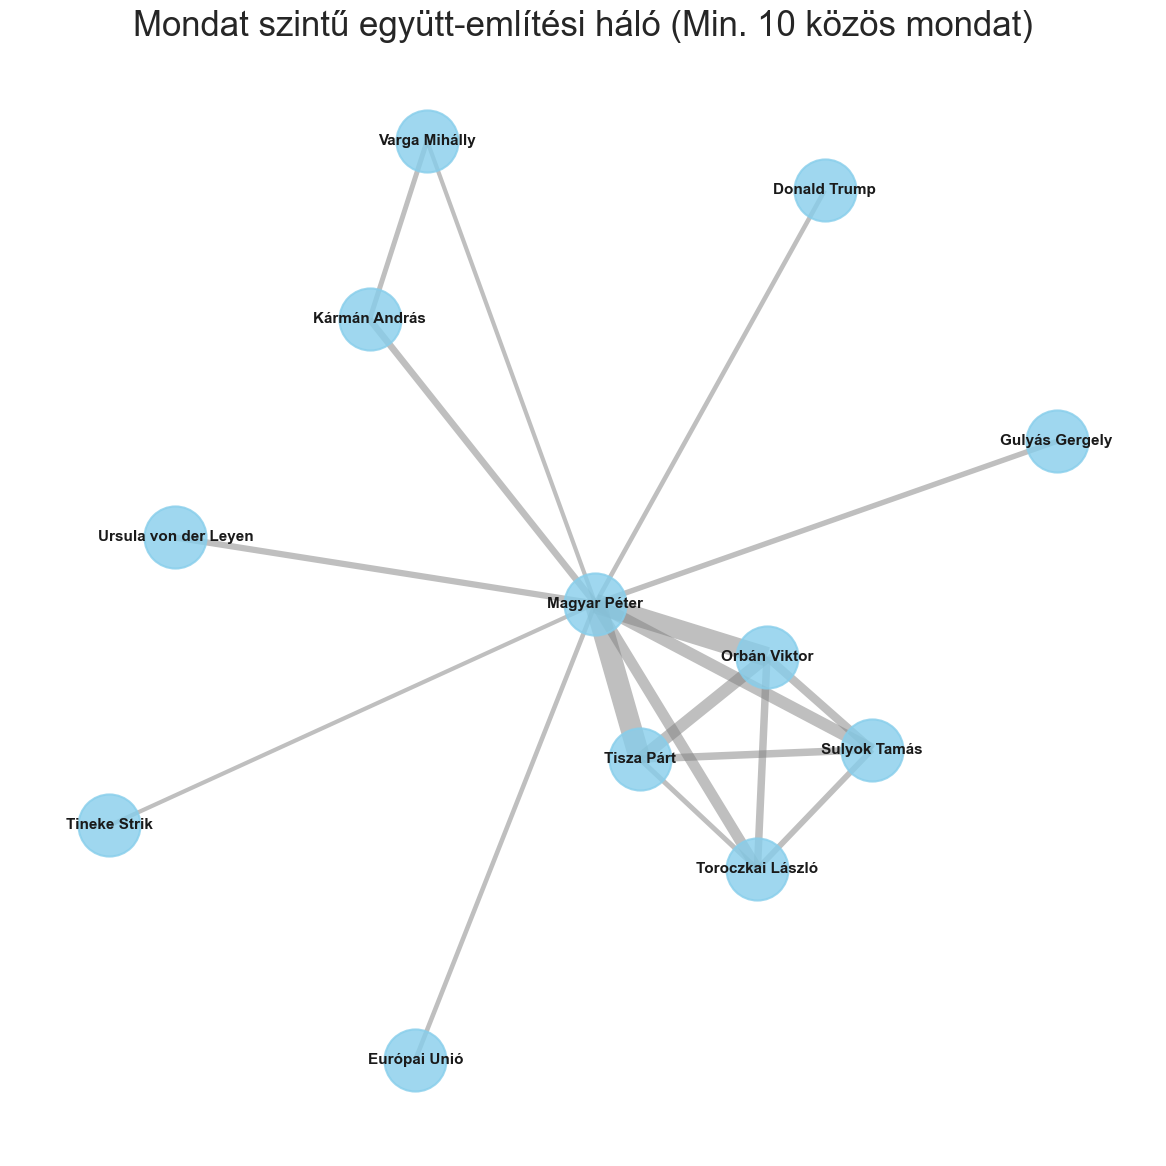

In [574]:
plt.figure(figsize=(12, 12))
    
# line's width based on frequency
min_cooccurrence = 10
G =  generate_cooccurrence_graph(news, min_cooccurrence=min_cooccurrence, before_election=False)
edges = G.edges()
weights = [G[u][v]['weight']*3 / min_cooccurrence for u, v in edges]

pos = nx.spring_layout(G, k=1, iterations=50, seed = 4) 
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

plt.title(f'Mondat szintű együtt-említési háló (Min. {min_cooccurrence} közös mondat)', fontsize=25)
plt.axis('off') # Hálózatnál a keret felesleges
plt.tight_layout()
plt.show()

### ADJs before and after the elections

In [564]:
news

,id,text,lemma,upos,ner,feats,deprel,date,next_lemma,sentence_id
0,1,Titkos,titkos,ADJ,O,Case=Nom|Degree=Pos|Number=Sing,amod:att,2026-03-30,tisza-terv,1
1,2,Tisza-tervet,tisza-terv,NOUN,O,Case=Acc|Number=Sing,obj,2026-03-30,hoz,1
2,3,hozott,hoz,VERB,O,Definite=Ind|Mood=Ind|Number=Sing|Person=3|Ten...,root,2026-03-30,nyilvánosság,1
3,4,nyilvánosságra,nyilvánosság,NOUN,O,Case=Sbl|Number=Sing,obl,2026-03-30,Csere Balázs,1
4,5,Csere Balázs,Csere Balázs,PROPN,B-PER,Case=Nom|Number=Sing,nsubj,2026-03-30,ki+vez,1
...,...,...,...,...,...,...,...,...,...,...
34235,3,25,25,NUM,O,Case=Nom|NumType=Card|Number=Sing,parataxis,2026-04-25,marad,2257
34244,1,Maradjanak,marad,VERB,O,Definite=Ind|Mood=Imp|Number=Plur|Person=3|Ten...,root,2026-04-25,nemsokára,2258
34247,4,nemsokára,nemsokára,ADV,O,None,advmod:tlocy,2026-04-25,kezdődik,2258
34248,5,kezdődik,kezdődik,VERB,O,Definite=Ind|Mood=Ind|Number=Sing|Person=3|Ten...,conj,2026-04-25,Nemzeti Sporthíradó Könyves Bence,2258


In [565]:
election_date = pd.to_datetime('2026-04-12')

df_before = news[news['date'] <= election_date]
df_after = news[news['date'] > election_date]

In [566]:
adjectives_before = df_before[df_before['upos'] == 'ADJ']['lemma'].str.lower().tolist()
adjectives_after = df_after[df_after['upos'] == 'ADJ']['lemma'].str.lower().tolist()
top_adj_before = Counter(adjectives_before).most_common(15)
top_adj_after = Counter(adjectives_after).most_common(15)

In [567]:
top_adj=pd.concat([pd.DataFrame(top_adj_before), pd.DataFrame(top_adj_after)], axis=1)
top_adj.columns=['before_elections', 'before_freq', 'after_elections', 'after_freq']

In [568]:
density_before = len(adjectives_before) / len(df_before) if len(df_before) > 0 else 0
density_after = len(adjectives_after) / len(df_after) if len(df_after) > 0 else 0
print(f"density change of adjective: {density_before:.2%} -> {density_after:.2%}")

density change of adjective: 19.52% -> 18.73%


In [569]:
top_adj

,before_elections,before_freq,after_elections,after_freq
0,magyar,78,új,36
1,amerikai,56,alakuló,23
2,védett,51,köztársasági,21
3,nagy,36,első,12
4,ukrán,35,ukrán,12
5,orosz,33,nagy,12
6,iráni,29,várható,12
7,olyan,21,magyar,12
8,fontos,18,amerikai,11
9,közösségi,17,leendő,11


### ADJs in one sentence with Magyar Peter

In [570]:
import pandas as pd
from collections import Counter

def get_top_context_extended(df, person_name, pos_tag='ADJ', top_n=10, before_election=True):
    """
    Identifies the most frequent words in the sentence of the mention 
    AND the following two sentences.
    """
    # 1. Setup election boundary
    election_date = pd.to_datetime('2026-04-12')
    
    # 2. Filter by period first
    if before_election:
        work_df = df[df['date'] < election_date].copy()
    else:
        work_df = df[df['date'] >= election_date].copy()
        
    if work_df.empty:
        print(f"No data found for the selected period.")
        return []

    # 3. Generate unique sentence identifiers
    work_df['sentence_uid'] = (work_df['id'] == 1).cumsum()
    
    # 4. Find sentences where the person is mentioned
    mention_sentence_ids = work_df[work_df['lemma'] == person_name]['sentence_uid'].unique()
    
    if len(mention_sentence_ids) == 0:
        print(f"No matches found for: {person_name} in this period.")
        return []

    # 5. Extend context: Include current sentence + next 2 sentences
    # We use a set to avoid duplicate sentence IDs
    extended_ids = set()
    for s_id in mention_sentence_ids:
        extended_ids.update([s_id, s_id + 1, s_id + 2])

    # 6. Extract words from the extended range
    context_words = work_df[
        (work_df['sentence_uid'].isin(extended_ids)) & 
        (work_df['upos'] == pos_tag) & 
        (work_df['lemma'] != person_name)
    ]['lemma'].str.lower().tolist()
    
    # 7. Calculate frequencies
    counts = Counter(context_words).most_common(top_n)
    
    # Output info
    period_str = "BEFORE" if before_election else "AFTER"
        
    return counts

In [571]:
get_top_context_extended(news, "Magyar Péter", pos_tag='ADJ', top_n=5, before_election=True)

[('magyar', 14), ('ukrán', 10), ('védett', 8), ('orosz', 6), ('amerikai', 5)]

In [572]:
get_top_context_extended(news, "Magyar Péter", pos_tag='ADJ', top_n=5, before_election=False)

[('új', 19),
 ('köztársasági', 17),
 ('alakuló', 15),
 ('magyar', 8),
 ('leendő', 8)]

### BERTopic modelling

In [16]:
pd.DataFrame([1, 2, 3])

NameError: name 'pd' is not defined

In [ ]:
from sentence_transformers import SentenceTransformer

# Extract texts from the dataframe
speech_text= df['cleaned_text'].tolist()

# Create an embedding using the specified model
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(speech_text, show_progress_bar=True)